In [407]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [408]:
reporting_directory_path = "app/analytical-backend/data/08_reporting/"
simulation_output_directory = "simulation_output"

In [409]:
## Data loading

all_vintage_data = pd.read_csv("app/analytical-backend/data/0_source/00_extract_vintagedata.csv", decimal=",")
current_vintage_data = pd.read_csv(os.path.join(reporting_directory_path, "PCEC96.csv"))

/var/folders/3k/vh6dl_9j30z3n567nqndm7tw0000gp/T/ipykernel_70065/894274059.py:3: DtypeWarning: Columns (2,8,9,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  all_vintage_data = pd.read_csv("app/analytical-backend/data/0_source/00_extract_vintagedata.csv", decimal=",")


In [410]:
last_sim = pd.read_excel(os.path.join(reporting_directory_path, simulation_output_directory, "sim202204.xlsx"), sheet_name="Nowcast Browser – Base")

In [411]:
simulation_outputs = []
for fname in os.listdir(os.path.join(reporting_directory_path, simulation_output_directory)):
    if not fname.endswith("xlsx"): continue
    fpath = os.path.join(reporting_directory_path, simulation_output_directory, fname)

    ts = pd.read_excel(fpath, sheet_name="Nowcast Browser – Base")
    cards = pd.read_excel(fpath, sheet_name="Cards")
    row = ts.loc[ts["Actual"].isna()]
    simulation_outputs.append({
        "ReferenceDate": row["Reference Date"].item(),
        "Predicted": row["Predicted"].item(),
        "ARIMA": cards.loc[cards["Card"] == "ARIMA"]["Value"].item(),
        "VAR": cards.loc[cards["Card"] == "VAR"]["Value"].item(),
        })

In [412]:
# Data processing

## Early estimates
all_vintage_data = all_vintage_data.loc[all_vintage_data["VariableCode"] == "PCEC96"]
cols = ["ReferenceDate", "PublicationDate"]
all_vintage_data[cols] = all_vintage_data[cols].apply(pd.to_datetime)
mask = all_vintage_data.groupby("ReferenceDate").agg({"PublicationDate": "min"})
early_estimates = pd.merge(all_vintage_data, mask.reset_index(), on=cols, how="right")
early_estimates = early_estimates.set_index("ReferenceDate").sort_index()
early_estimates.index = early_estimates.index.strftime("%Y-%m-%d")
# date_range = pd.to_datetime(["2020-03-01", "2020-05-01"])  # sanity check for the 1st. publication date
# display(early_estimates.loc[early_estimates["ReferenceDate"].between(date_range[0], date_range[1])])
# all_vintage_data.loc[all_vintage_data["ReferenceDate"].between(date_range[0], date_range[1])].sort_values(by=cols)

## Current-vintage data
current_vintage_data["observation_date"] = pd.to_datetime(current_vintage_data["observation_date"])
current_vintage_data = current_vintage_data.rename(columns={
    "observation_date": "ReferenceDate",
    "PCEC96": "VariableValue"
})
current_vintage_data = current_vintage_data.set_index("ReferenceDate").sort_index()
current_vintage_data.index = current_vintage_data.index.strftime("%Y-%m-%d")

## Predictions
simulation_df = pd.DataFrame(simulation_outputs)
simulation_df = simulation_df.set_index("ReferenceDate").sort_index()
simulation_df.index = simulation_df.index.strftime("%Y-%m-%d")

In [413]:
# Residual Learning (Meta Model)

pred_act = pd.merge(
    early_estimates[["VariableValue"]],
    simulation_df, 
    how="left",
    left_index=True,
    right_index=True
)

In [414]:
pred_act["Lag"] = pred_act["VariableValue"].shift()

pred_act["Predicted - Lag"] = pred_act["Predicted"] - pred_act["Lag"]
pred_act["Nowcast Change (MoM)"] = pred_act["Predicted"] - pred_act["Predicted"].shift()
pred_act["Lag(Actual Change (MoM))"] = (pred_act["VariableValue"] - pred_act["Lag"]).shift()

pred_act["Expanding25th"] = pred_act["Lag(Actual Change (MoM))"].dropna().expanding().apply(lambda x: np.percentile(x, 25), raw=True)
pred_act["Expanding50th"] = pred_act["Lag(Actual Change (MoM))"].dropna().expanding().apply(lambda x: np.percentile(x, 50), raw=True)
pred_act["Expanding75th"] = pred_act["Lag(Actual Change (MoM))"].dropna().expanding().apply(lambda x: np.percentile(x, 75), raw=True)
pred_act["IQR"] = pred_act["Expanding75th"] - pred_act["Expanding25th"]

# pred_act["RollingMean"] = pred_act["Lag Change (MoM)"].dropna().rolling(window=3, min_periods=1).mean()

In [415]:
iqrs = 1.5
pred_act["Upper"] = pred_act["Expanding75th"] + iqrs * pred_act["IQR"]
pred_act["Lower"] = pred_act["Expanding25th"] - iqrs * pred_act["IQR"]

# stds = 3
# pred_act["Upper"] = pred_act["RollingMean"] + stds * pred_act["RollingStd"]
# pred_act["Lower"] = pred_act["RollingMean"] - stds * pred_act["RollingStd"]

In [416]:
pred_act = pred_act.dropna(subset=["Predicted"])

pred_act["Flag"] = (
    (~pred_act["Predicted - Lag"].between(pred_act["Lower"], pred_act["Upper"])) &
    (pred_act["Predicted - Lag"].abs() > pred_act["Lag(Actual Change (MoM))"].abs().rolling(2).mean()) &
    ((pred_act["Predicted - Lag"]/pred_act["Lag"]).abs() > 0.02) #&
    # (pred_act["Nowcast Change (MoM)"].abs() > 250)
)
print(pred_act["Flag"].shape, pred_act["Flag"].sum())

# rev_nowcast = None

# nowcast = []
# for i in range(pred_act.shape[0]):

#     curr = pred_act.loc[pred_act.index[i]]

#     if i == 0:
#         lag = curr["Lag"]
#         adjusted_nowcast = lag + (np.sign(curr["Nowcast Change (MoM)"])) * np.abs(curr["Expanding50th"]) if curr["Flag"].item() else curr["Predicted"].item()
#     else:
#         lag = pred_act.loc[pred_act.index[i-1]]
#         adjusted_nowcast = prev_nowcast + (np.sign(curr["Nowcast Change (MoM)"])) * np.abs(curr["Expanding50th"]) if curr["Flag"].item() else curr["Predicted"].item()

#     prev_nowcast = adjusted_nowcast
#     nowcast.append(adjusted_nowcast)



adjusted_nowcast = pred_act["Lag"] + (np.sign(pred_act["Nowcast Change (MoM)"])) * (pred_act["Lag(Actual Change (MoM))"]).abs()
pred_act["Nowcast"] = np.where(
    pred_act["Flag"],
    adjusted_nowcast,
    pred_act["Predicted"]
    )

(46,) 11


In [417]:
# Data to plot
nowcast_df = pred_act[["Nowcast"]]

idx = pd.date_range(start=nowcast_df.index.min(), end=nowcast_df.index.max(), freq='MS')
idx = idx.strftime("%Y-%m-%d")

df_plt = pd.concat([
    current_vintage_data.loc[idx].rename(columns={"VariableValue": "CurrentRelease"}), 
    early_estimates[["VariableValue"]].rename(columns={"VariableValue": "FirstRelease"}).loc[idx], 
    nowcast_df.loc[idx]
    ], axis=1)

df_plt.index = pd.to_datetime(df_plt.index)

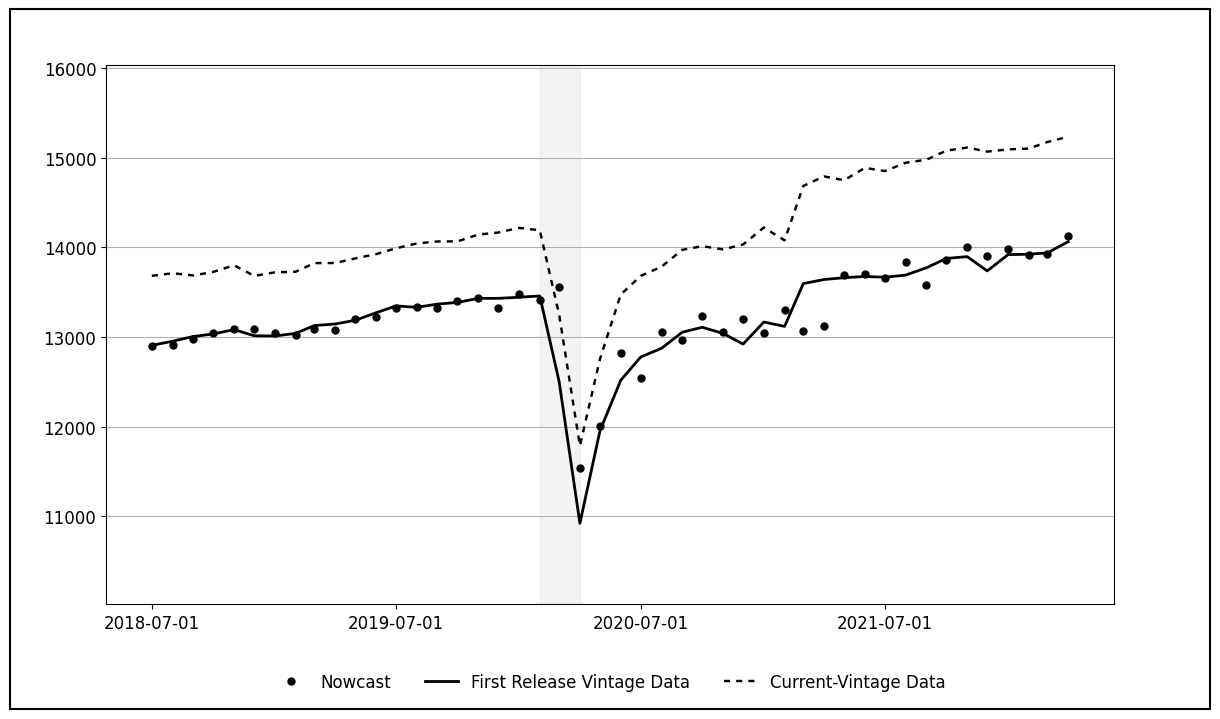

In [418]:
# Plot

# Assuming df_plt contains the data and you want to adjust the x-axis labels
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

# Plotting the 'CurrentRelease' data
line, = ax.plot(df_plt["CurrentRelease"], color='black', label='Current-Vintage Data', linestyle='-', marker='o', markersize=0, linewidth=1.75)
line.set_dashes([2.5, 2.5])

# Plotting the 'Nowcast' data
ax.plot(df_plt["Nowcast"], color='black', label='Nowcast', linestyle='-', marker='o', markersize=5, linewidth=0)
ax.grid(True, axis='y')

# Axes
y_range = [df_plt.min().min()-900, df_plt.max().max()+800]
ax.set_ylim(y_range)
for label in ax.get_yticklabels():
    label.set_fontsize(12)

ax.set_xticks(df_plt.index[::12])
ax.set_xticklabels(df_plt.index.strftime('%Y-%m-%d')[::12], fontsize=12)  # Format as year

# Plotting the 'FirstRelease' data with dashed line
ax.plot(df_plt["FirstRelease"], color='black', label='First Release Vintage Data', linestyle='-', marker='o', markersize=0, linewidth=2)

ax.fill_between(
        x=df_plt.loc["2020-02-01":"2020-04-01"].index, 
        y1=y_range[0], 
        y2=y_range[1],
        color="#938BA1",
        alpha=0.1)

# Adding legend inside the plot
handles, labels = ax.get_legend_handles_labels()
desired_order = ["Nowcast", "First Release Vintage Data", "Current-Vintage Data"]
order = [labels.index(label) for label in desired_order]
ax.legend(
    [handles[i] for i in order], [labels[i] for i in order],
    loc='upper center',
    fontsize=12,
    bbox_to_anchor=(0.5, -0.1),  # X center, Y below axis (tweak -0.15 as needed)
    ncol=3,  # Put items in one row (adjust based on how many items you have)
    frameon=False  # Optional: remove border
)

fig.subplots_adjust(left=0.08, right=0.92, top=0.92, bottom=0.15)

# Add outer frame (border)
frame = patches.Rectangle(
    (0, 0), 1, 1, transform=fig.transFigure,  # full figure (not just axes)
    fill=False,
    edgecolor='black',
    linewidth=1.5
)
fig.patches.append(frame)

# # Tight layout so legend doesn't get cut off
# plt.tight_layout()

plt.show()
